# Resistance Model

In [1]:
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from axiom.config import DATA_DIR

## Load the Data

In [2]:
TICKER = "SPY"

# SAVE_FN = f"{TICKER}_{datetime.now().strftime('%Y-%m-%d')}.csv"
SAVE_FN = "SPY_2024-07-14.csv"

SAVE_FP = DATA_DIR.joinpath("daily", SAVE_FN)
SAVE_FP.parent.mkdir(parents=True, exist_ok=True)

In [3]:
# # GET the data
# 
# from axiom.mdata.equity import get_daily_price_history, CandleList
# 
# data: CandleList = await get_daily_price_history(TICKER)
# 
# # Convert to DataFrame
# df = pd.DataFrame.from_records([candle.dict() for candle in data.candles])
# df.to_csv(SAVE_FP, index=False)

In [4]:
# Load the data
df = pd.read_csv(SAVE_FP)

## Process the data

In [5]:
# Filter columns
columns = ["datetime", "high", "low"]
df = df[columns]

# Convert int to datetime
df["datetime"] = pd.to_datetime(df["datetime"], unit="ms")

# Add a new column for the day of the week, 0=Monday, 6=Sunday
df["day"] = df["datetime"].dt.dayofweek

### Round the values

0-100 -> 0.1
100-200 -> 0.2
200-300 -> 0.3
...

This creates a more general resistance model that can be applied at different price levels.
It isn't perfect, but it's a good starting point.

In [6]:
# Round the high and low
def round_to_tick(value):
    tick = value // 100 or 1
    round_to = tick / 10
    return round(value / round_to) * round_to


# Apply the custom rounding to 'high' and 'low' columns
df["high"] = df["high"].apply(round_to_tick)
df["low"] = df["low"].apply(round_to_tick)

In [7]:
df.tail()

,datetime,high,low,day
5031,2024-07-08 05:00:00,556.5,554.0,0
5032,2024-07-09 05:00:00,557.0,555.5,1
5033,2024-07-10 05:00:00,561.5,557.0,2
5034,2024-07-11 05:00:00,562.5,556.0,3
5035,2024-07-12 05:00:00,563.5,557.0,4


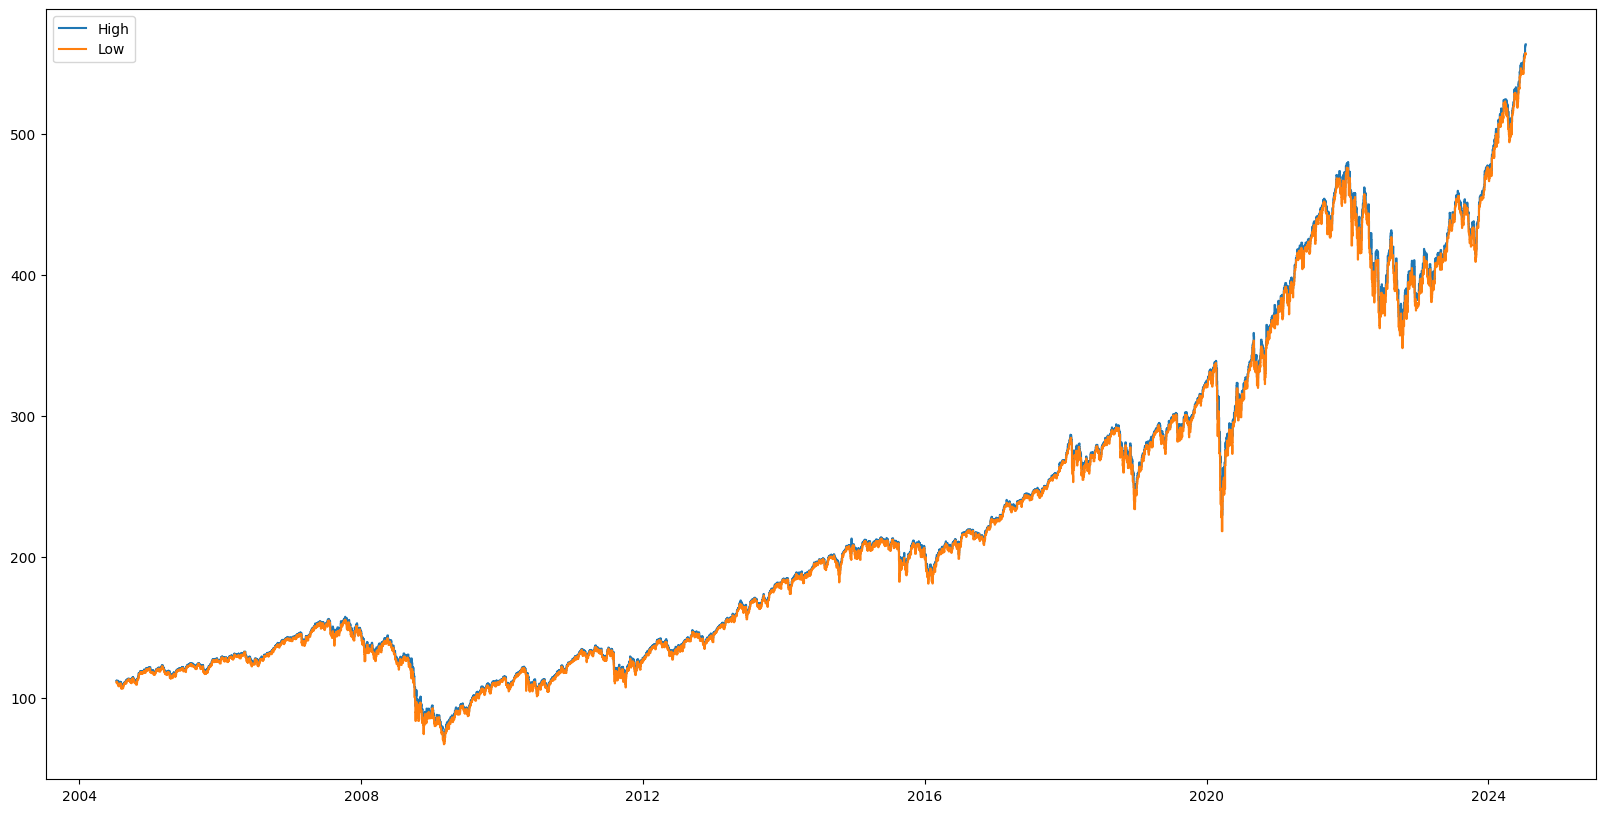

In [8]:
plt.figure(figsize=(20, 10))
plt.step(df["datetime"], df["high"], label="High")
plt.step(df["datetime"], df["low"], label="Low")
plt.legend()
plt.show()

In [9]:
# Calculate the common resistance levels
resistance_levels = df["high"].value_counts()

# Sort by most common resistance levels
resistance_levels = resistance_levels.sort_values(ascending=False)
resistance_levels.head(10)

high
209.8    14
127.4    13
210.4    13
132.8    12
111.7    12
210.6    12
208.2    12
128.4    12
120.0    12
207.4    11
Name: count, dtype: int64

## Prepare the dataset

We will use the high prices of the last 5 days ending on a friday to predict the high price of next week.

In [10]:
d_df = df.copy()

# Filter for Fridays (day == 4)
fridays = d_df[d_df['day'] == 4].reset_index(drop=True)

# Create features and labels
features = []
labels = []

for i in range(len(fridays) - 1):
    friday_date = fridays.loc[i, 'datetime']
    next_friday_date = fridays.loc[i + 1, 'datetime']

    # Filter the last 5 days ending on this Friday
    last_5_days = d_df[(d_df['datetime'] <= friday_date) & (d_df['datetime'] > friday_date - pd.Timedelta(days=5))]

    # Check if we have exactly 5 days
    if len(last_5_days) == 5:
        # Create the feature vector of the high prices of the last 5 days
        feature_vector = last_5_days['high'].values

        # Filter the next week's data
        next_week_data = d_df[
            (d_df['datetime'] > friday_date) & (d_df['datetime'] <= friday_date + pd.Timedelta(days=7))]

        # Check if we have at least one day in the next week
        if not next_week_data.empty:
            # The label is the maximum high price of the next week
            label = next_week_data['high'].max()

            features.append(feature_vector)
            labels.append(label)

# Convert to numpy arrays
X = np.array(features)
y = np.array(labels)

# Verify the shapes
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (861, 5)
Labels shape: (861,)


## Train the model

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from xgboost import XGBRegressor

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 430
Testing set size: 431


In [13]:
# Print the first 5 samples
for i in range(5):
    print(X_train[i], y_train[i])

[104.3 106.1 105.9 107.2 107.3] 109.7
[276.6 275.8 276.8 276.  275.8] 273.8
[303.9 304.2 304.5 304.2 306.3] 309.59999999999997
[191.9 189.7 191.8 192.5 195. ] 202.0
[119.8 118.8 118.5 119.1 118.7] 122.9


In [14]:
# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_train_xgb = xgb_model.predict(X_train_scaled)
y_pred_test_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Regressor Performance:")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train_xgb):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred_test_xgb):.4f}")
print(f"Train R2: {r2_score(y_train, y_pred_train_xgb):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_test_xgb):.4f}")
print()

XGBoost Regressor Performance:
Train MSE: 1.5619
Test MSE: 24.0142
Train R2: 0.9999
Test R2: 0.9982



In [17]:
# Test the model with manual data
# This data is for the week of 2024 July 8th to 12th
last_5_days = np.array([556.5, 557.0, 561.5, 562.5, 563.5])

last_5_days_scaled = scaler.transform(last_5_days.reshape(1, -1))
next_week_high = xgb_model.predict(last_5_days_scaled)
print("Next week's high price prediction:", next_week_high[0])

Next week's high price prediction: 553.681
